# CommonRoad Monitor Scenario Evaluation


### Import Modules

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%matplotlib notebook
import matplotlib.pyplot as plt
from IPython import display
from ipywidgets import widgets


from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.scenario.obstacle import DynamicObstacle
from commonroad.visualization.draw_dispatch_cr import draw_object
from commonroad.visualization.plot_helper import *

from src.common.helper import *
from src.monitor.traffic_rule_dispatcher import TrafficRuleDispatcher
from src.common.vehicle import Vehicle
from src.common.road_network import RoadNetwork
from src.common.commonroad_evaluation import CommonRoadObstacleEvaluation
from src.output.visualization import Visualization

### Load scenario

In [8]:
scenario_path = "../scenarios/test/" # "../../../commonroad/scenarios/highD-dataset/cr_scenarios/" 
scenarios = {1: "DEU_test_max_speed_limit",
             2: "DEU_test_min_speed_limit",
             3: "DEU_test_preserve_traffic_flow",
             4: "DEU_test_safe_distance",
             5: "DEU_test_standstill",
             6: "DEU_test_unnecessary_braking_1",
             7: "DEU_test_unnecessary_braking_2",
             8: "DEU_test_reversing_and_u_turn",
             9: "DEU_test_emergency_three_lanes_with_shoulder",
            10: "DEU_test_overtaking_exit_ramp",
            11: "DEU_test_overtaking_access_ramp",
            12: "DEU_test_overtaking_right_congestion",
            13: "DEU_test_overtaking_right_broad_lane_marking",
            14: "DEU_test_overtaking_right_normal",
            15: "DEU_test_consider_entering_vehicles",
            16: "DEU_test_emergency_two_lanes_not_broad_enough",
            17: "DEU_LocationE-24_21_T-1"}
selected_scenario = 15

In [9]:
scenario, planning_problem_set = \
            CommonRoadFileReader(scenario_path + scenarios.get(selected_scenario) + ".xml").open()
cr_eval = CommonRoadObstacleEvaluation("../src/")

### Auxiliary Functions

In [10]:
def get_max_time():
    max_time = 0
    for obs in scenario.dynamic_obstacles:
        if obs.prediction.trajectory.state_list[-1].time_step > max_time:
            max_time = obs.prediction.trajectory.state_list[-1].time_step
    return max_time

### Plot scenario

<IPython.core.display.Javascript object>


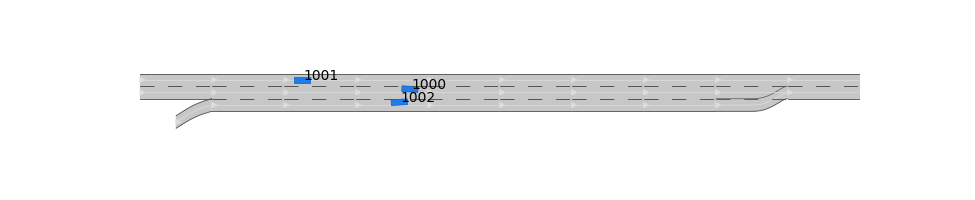

interactive(children=(IntSlider(value=0, description='t', max=50), Output()), _dom_classes=('widget-interact',…

In [11]:
vis = Visualization(figsize=(9.75,2))
def draw_state(t):
    print("current time step: ", t)
    vis.plot_scenario(scenario, time_begin=t, obstacle_label=True, lanelet_label=False)

# use the slider to have at look at every time step of the planned trajectory
w = widgets.interact(draw_state, t=widgets.IntSlider(min=0, max=get_max_time(), step=1, value=0))

### Rule evaluation

In [6]:
rule_sets = ["F_SRI4"]
eval_result = cr_eval.evaluate_scenario(scenario, rule_sets)

TypeError: evaluate_scenario() takes 2 positional arguments but 3 were given